In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
import pandas as pd

file_path = r"C:\Users\Aishwarya\Downloads\house-prices-advanced-regression-techniques\train.csv"

df = pd.read_csv(file_path)

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(1460, 81)


In [4]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'Pool

In [5]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null  

In [6]:
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
print("Target Variable: SalePrice")

print("Minimum Price :", df["SalePrice"].min())
print("Maximum Price :", df["SalePrice"].max())
print("Mean Price    :", df["SalePrice"].mean())
print("Median Price  :", df["SalePrice"].median())

Target Variable: SalePrice
Minimum Price : 34900
Maximum Price : 755000
Mean Price    : 180921.19589041095
Median Price  : 163000.0


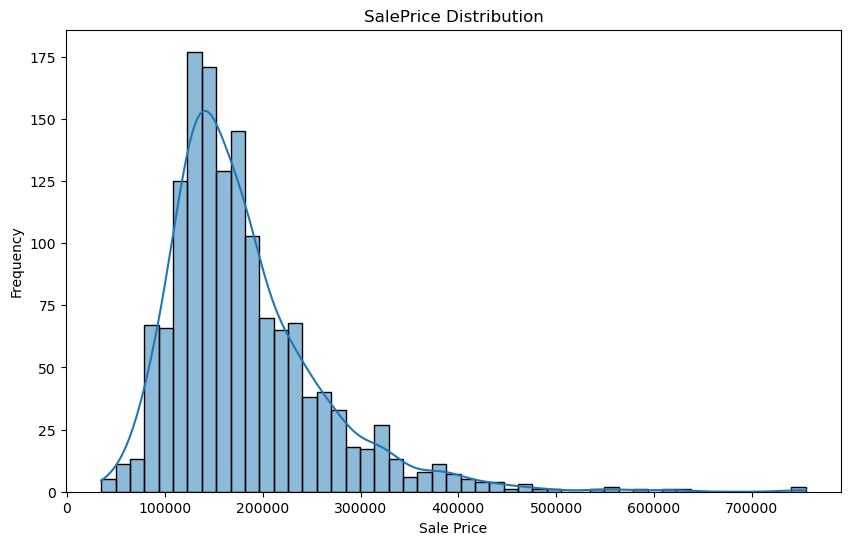

In [8]:
plt.figure(figsize=(10, 6))

sns.histplot(df["SalePrice"], kde=True)

plt.title("SalePrice Distribution")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

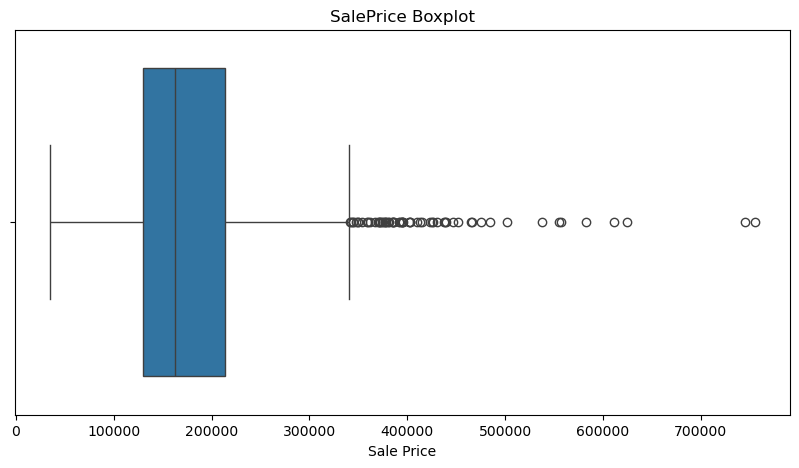

In [9]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["SalePrice"])

plt.title("SalePrice Boxplot")
plt.xlabel("Sale Price")

plt.show()

In [10]:
# MISSING VALUE ANALYSIS

missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(
    ascending=False
)

print("Columns with missing values:")
display(missing)

Columns with missing values:


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

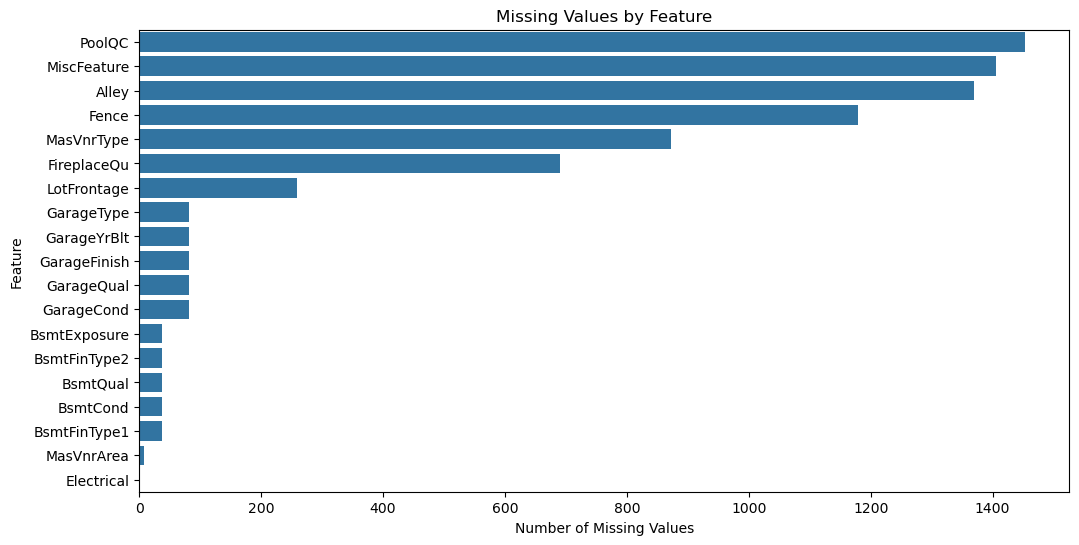

In [11]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=missing.values,
    y=missing.index
)

plt.title("Missing Values by Feature")
plt.xlabel("Number of Missing Values")
plt.ylabel("Feature")

plt.show()

In [12]:
# DUPLICATE ANALYSIS

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [13]:
# NUMERICAL FEATURE ANALYSIS

numeric_columns = df.select_dtypes(include=np.number).columns

print("Number of numerical columns:", len(numeric_columns))
print("\nNumerical columns:")
print(numeric_columns.tolist())

Number of numerical columns: 38

Numerical columns:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


In [14]:
# CATEGORICAL FEATURE ANALYSIS

categorical_columns = df.select_dtypes(include="object").columns

print("Number of categorical columns:", len(categorical_columns))
print("\nCategorical columns:")
print(categorical_columns.tolist())

Number of categorical columns: 43

Categorical columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


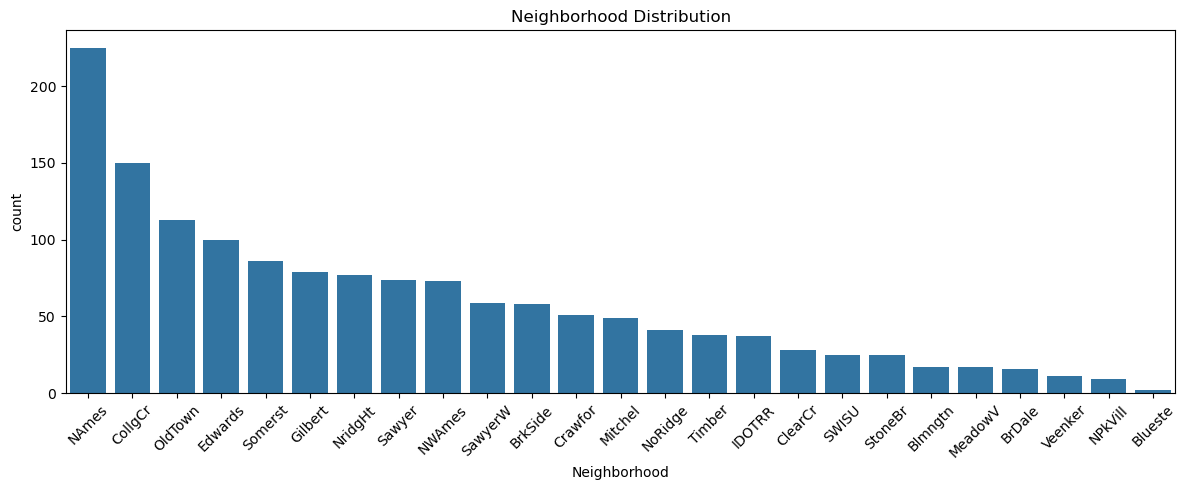

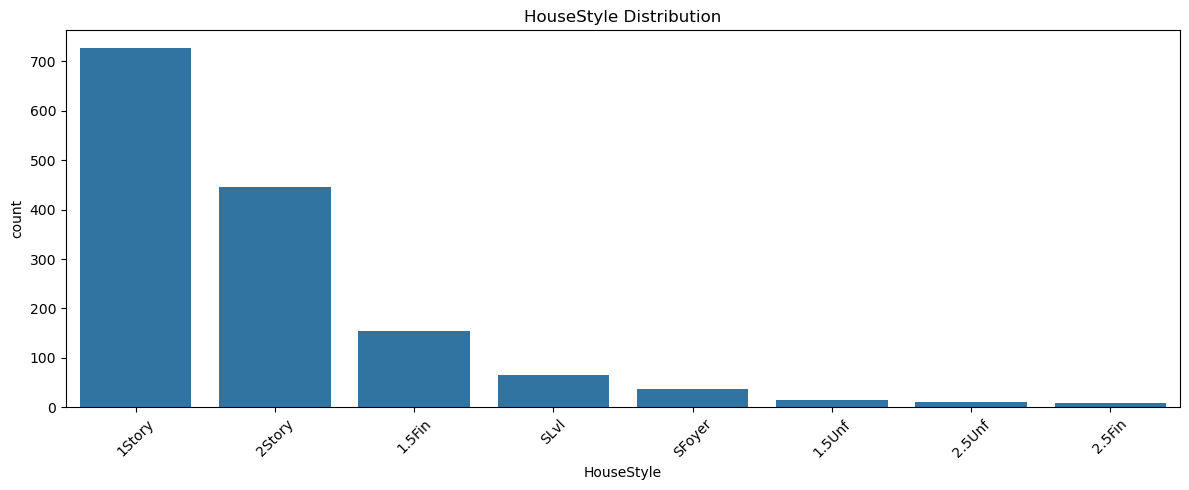

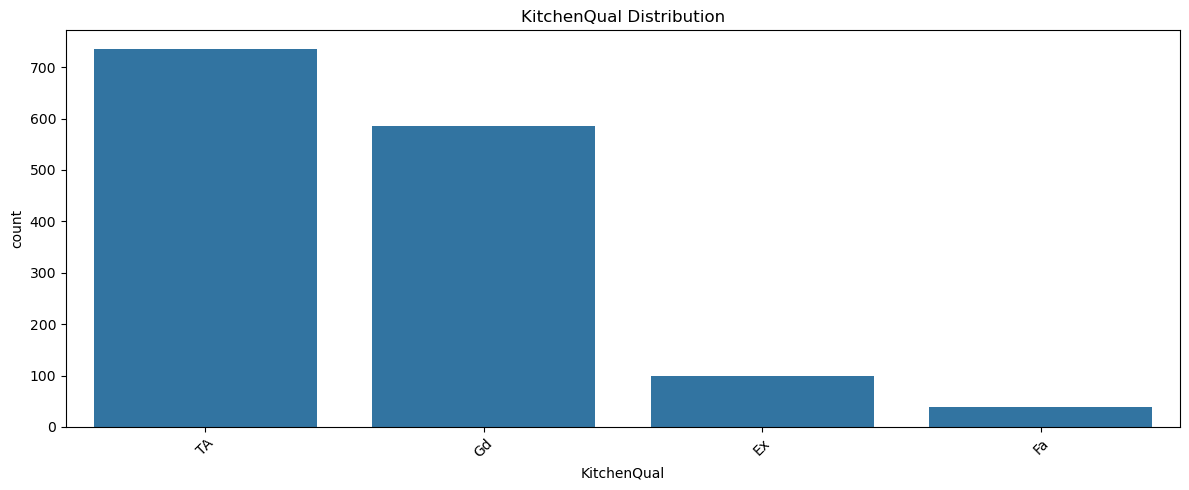

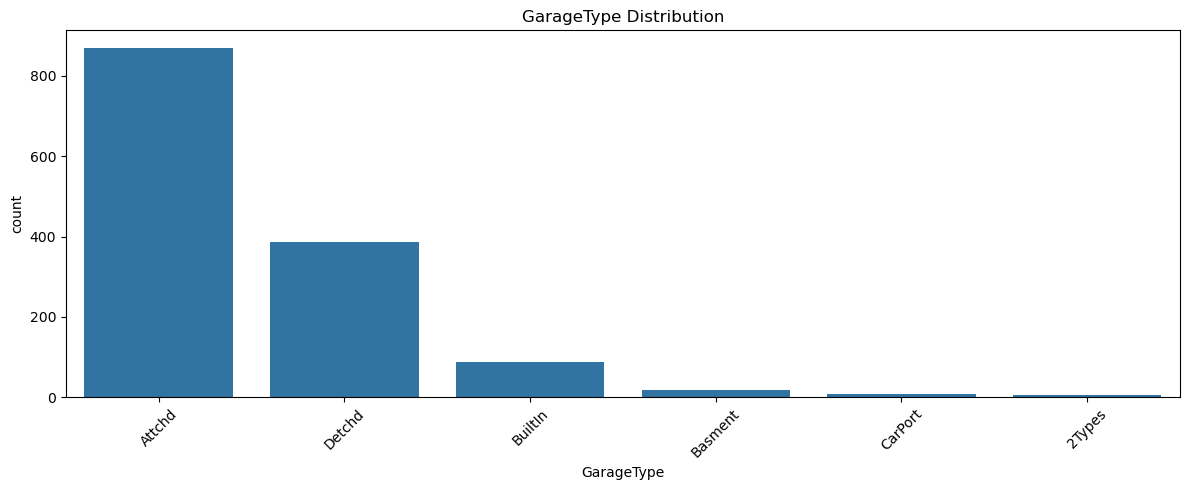

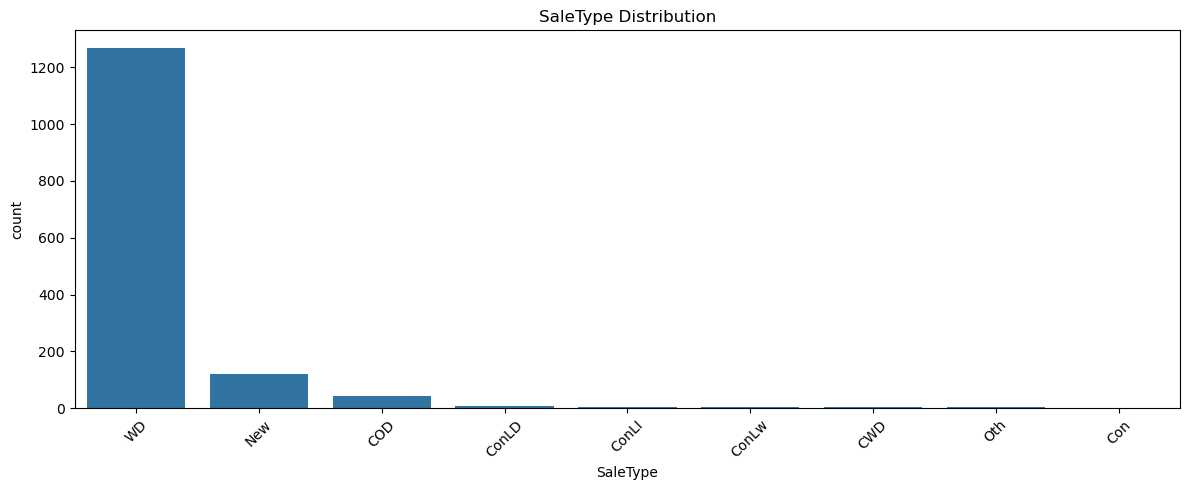

In [15]:
# IMPORTANT CATEGORICAL FEATURES

categorical_features = [
    "Neighborhood",
    "HouseStyle",
    "KitchenQual",
    "GarageType",
    "SaleType"
]

for col in categorical_features:
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

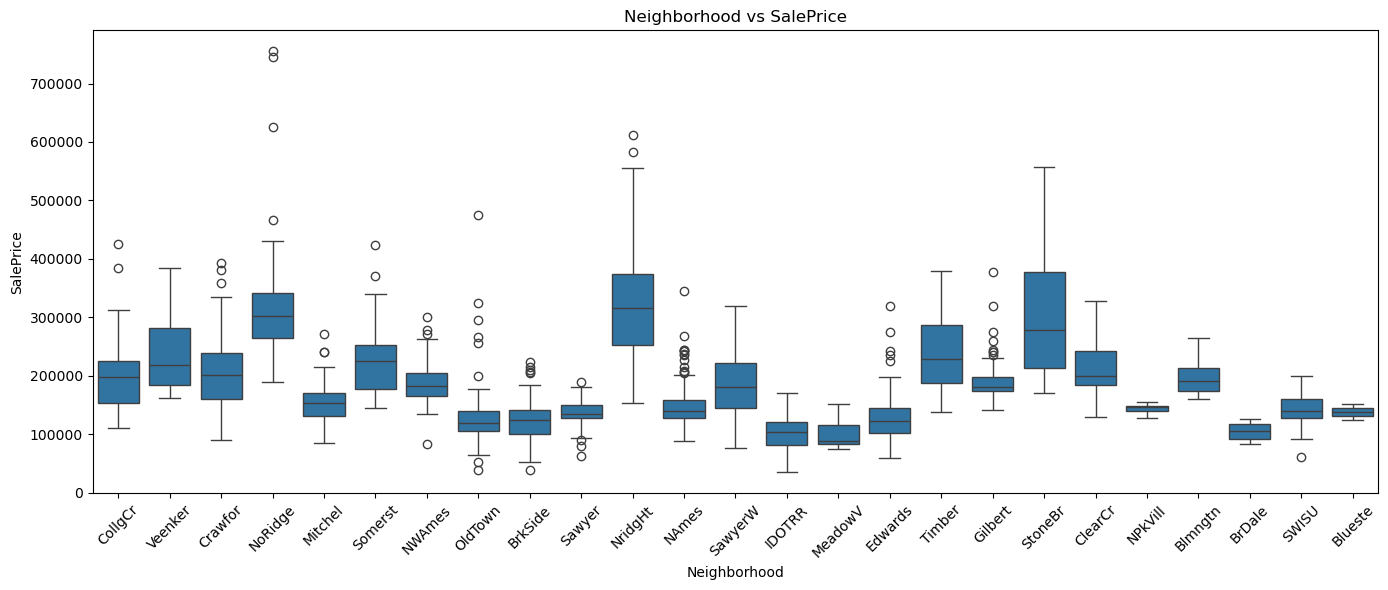

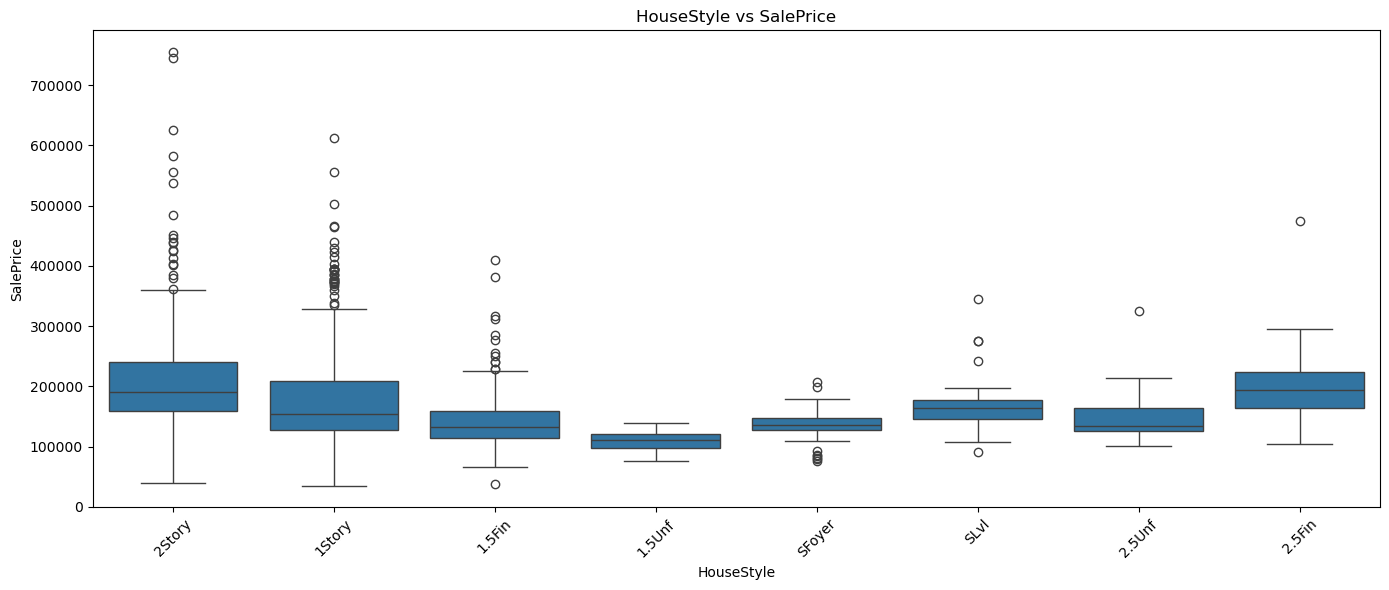

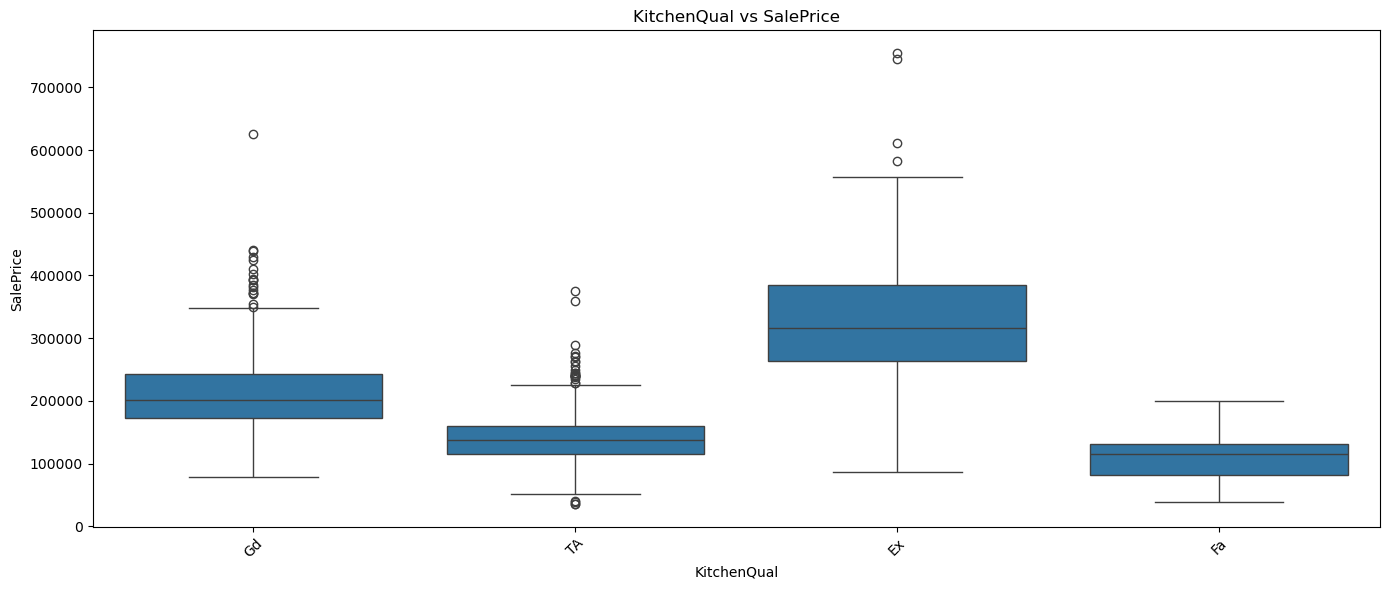

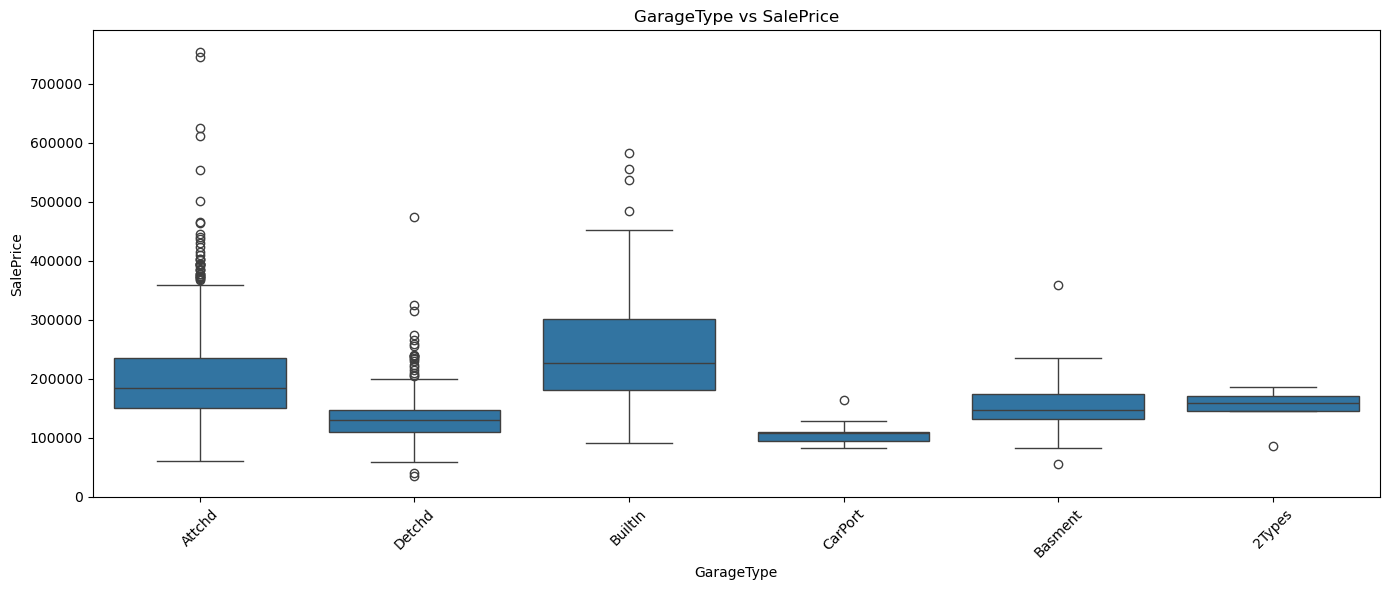

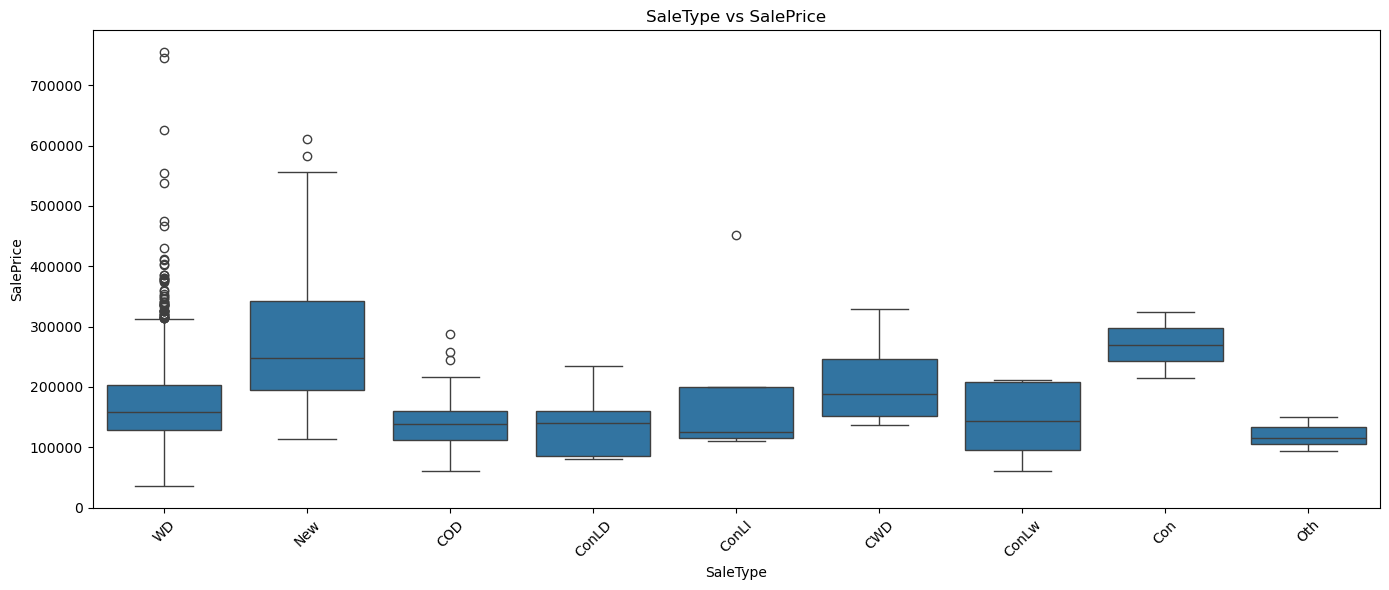

In [16]:
# CATEGORICAL FEATURES VS SALE PRICE

for col in categorical_features:
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df, x=col, y="SalePrice")
    plt.title(f"{col} vs SalePrice")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [17]:
# CORRELATION ANALYSIS

numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

saleprice_correlation = correlation["SalePrice"].sort_values(
    ascending=False
)

print("Features most positively correlated with SalePrice:")
display(saleprice_correlation.head(15))

Features most positively correlated with SalePrice:


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

In [18]:
# FEATURES WITH NEGATIVE CORRELATION

print("Features negatively correlated with SalePrice:")
display(saleprice_correlation.sort_values().head(10))

Features negatively correlated with SalePrice:


KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
Id              -0.021917
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
Name: SalePrice, dtype: float64

In [19]:
# TOP FEATURES CORRELATED WITH SALEPRICE

top_correlations = (
    saleprice_correlation
    .drop("SalePrice")
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

print("Top 15 features correlated with SalePrice:")
display(top_correlations)

Top 15 features correlated with SalePrice:


OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64

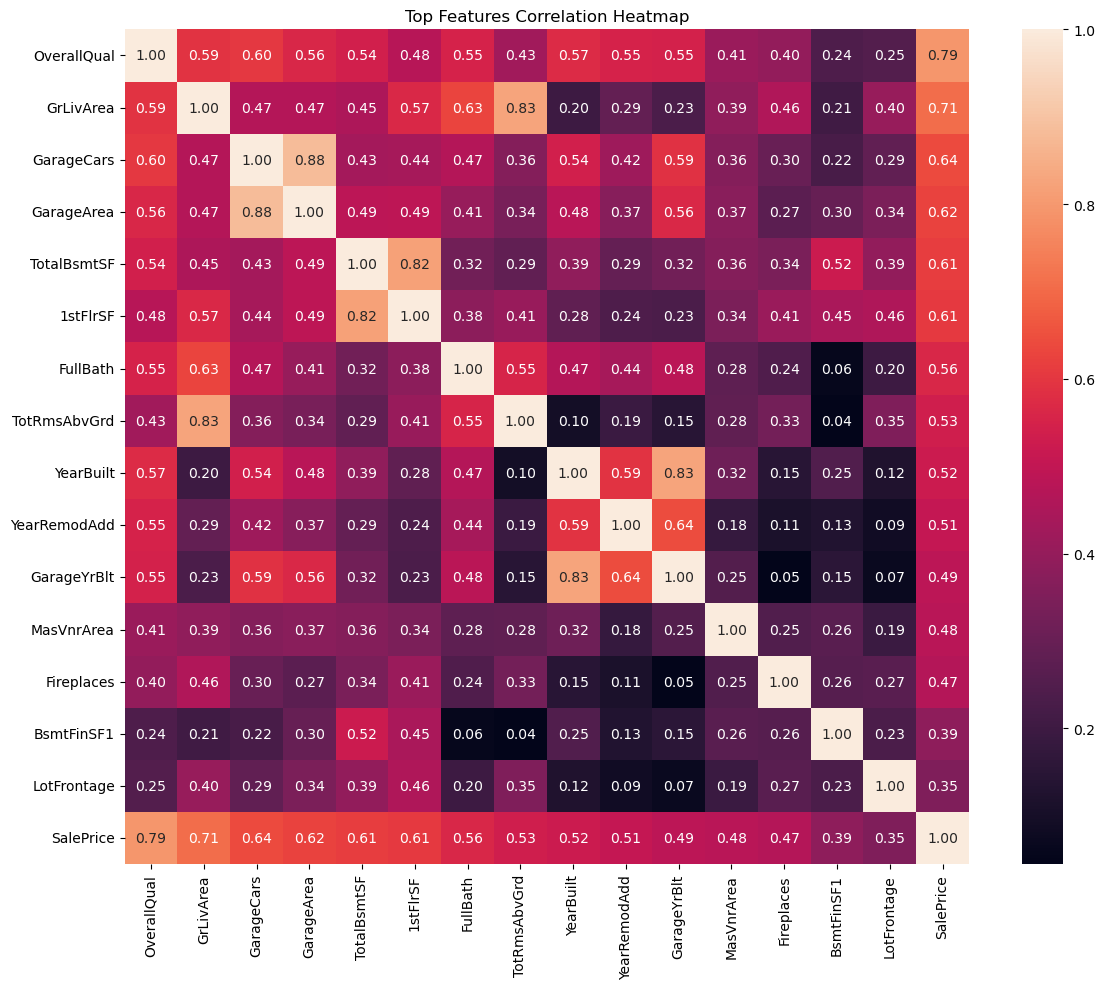

In [20]:
# CORRELATION HEATMAP

top_features = top_correlations.index.tolist()

# Add target variable
top_features.append("SalePrice")

plt.figure(figsize=(12, 10))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Top Features Correlation Heatmap")
plt.tight_layout()
plt.show()

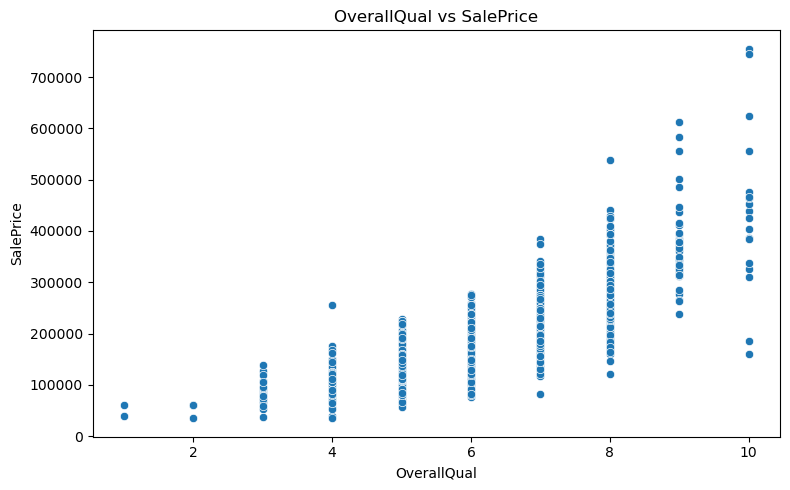

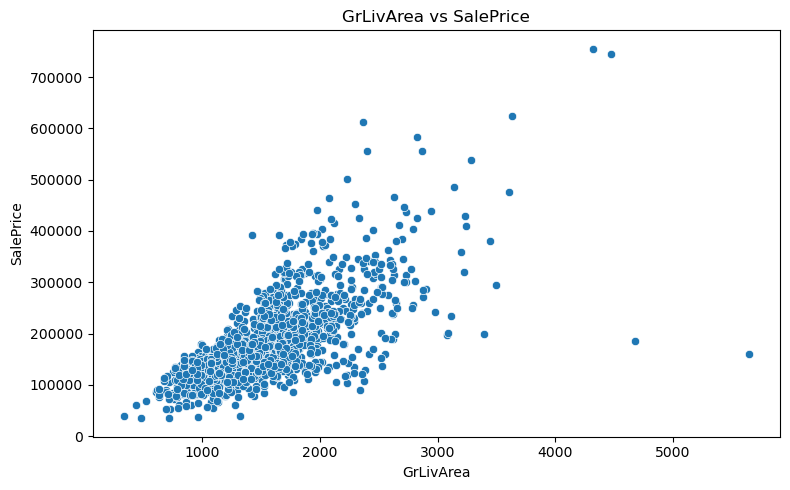

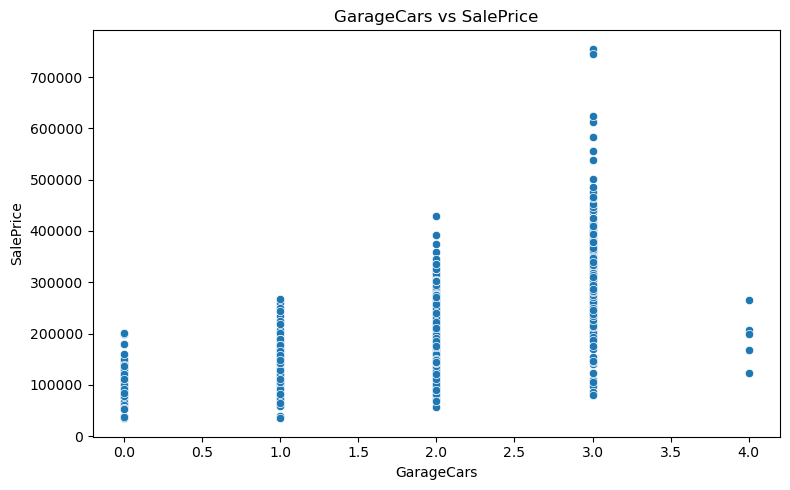

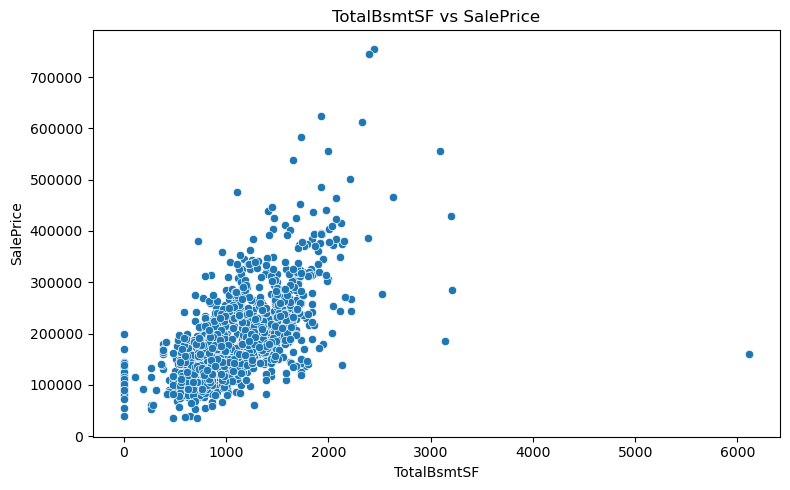

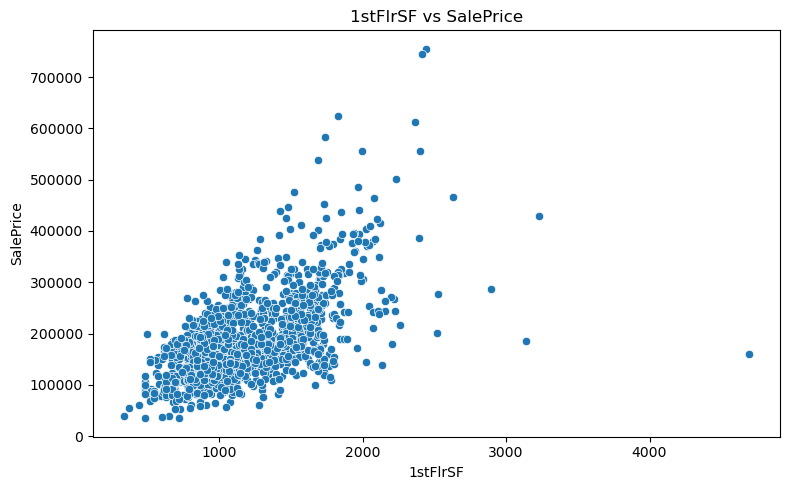

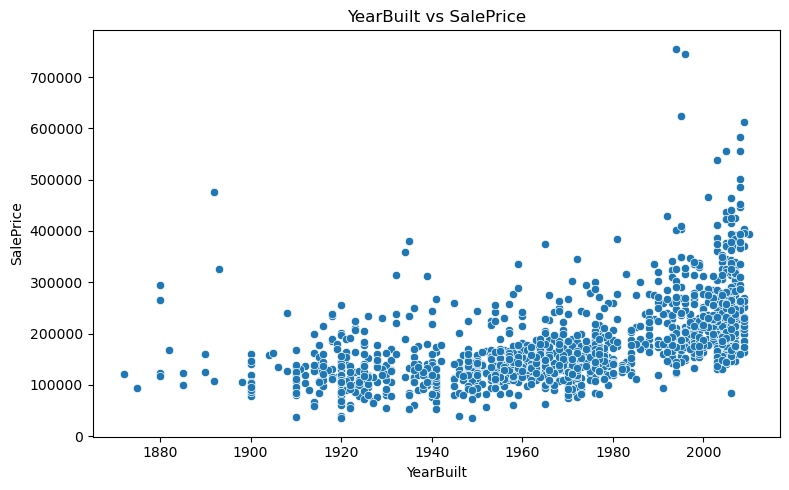

In [21]:
# IMPORTANT NUMERICAL FEATURES VS SALEPRICE

important_numeric_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "1stFlrSF",
    "YearBuilt"
]

for col in important_numeric_features:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=col, y="SalePrice")
    plt.title(f"{col} vs SalePrice")
    plt.tight_layout()
    plt.show()

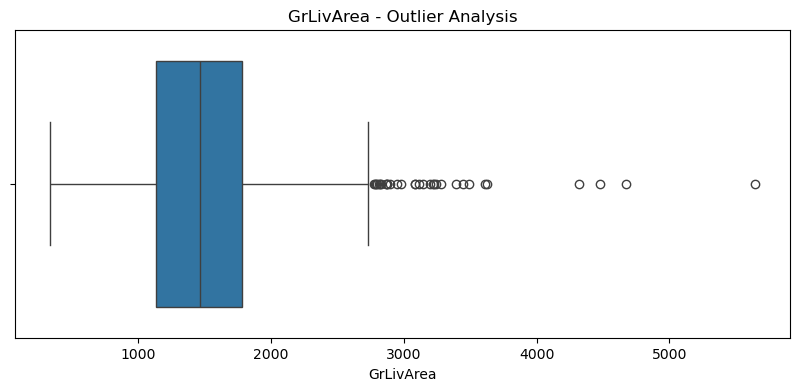

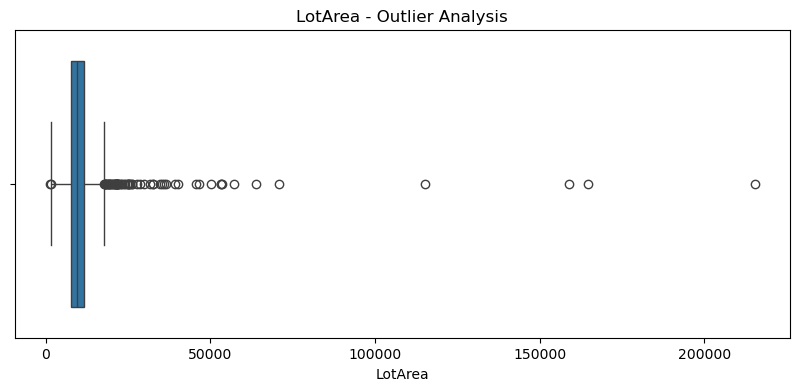

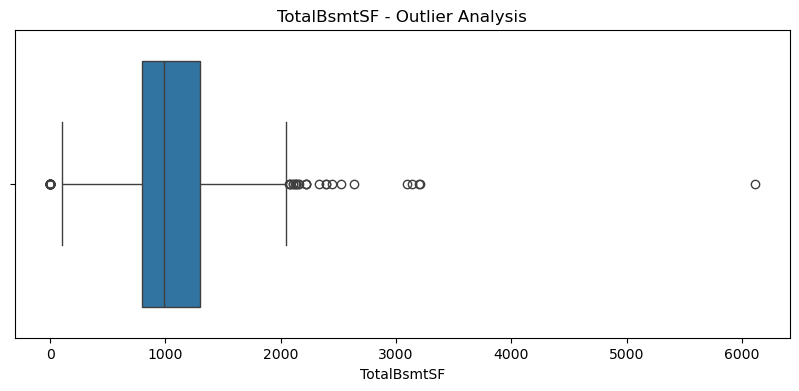

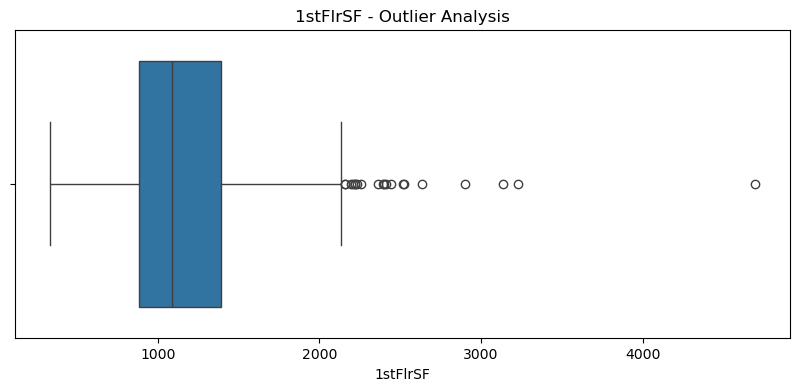

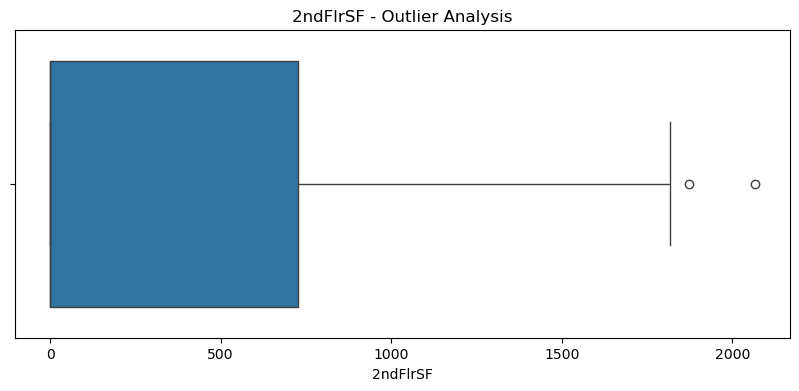

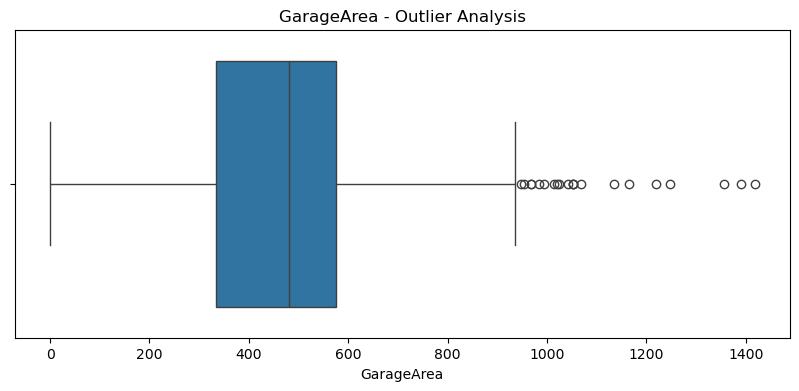

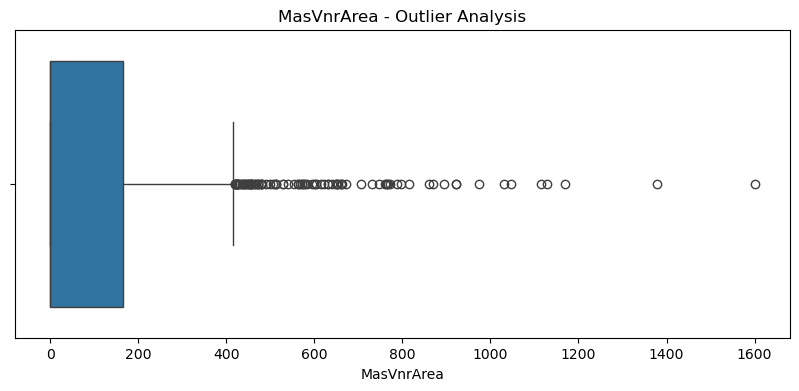

In [22]:
# OUTLIER ANALYSIS

outlier_features = [
    "GrLivArea",
    "LotArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "GarageArea",
    "MasVnrArea"
]

for col in outlier_features:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} - Outlier Analysis")
    plt.xlabel(col)
    plt.show()

In [23]:
# CHECK LARGE LIVING AREA VALUES

large_houses = df[df["GrLivArea"] > 4000]

print("Number of houses with GrLivArea > 4000:", len(large_houses))

display(
    large_houses[
        ["Id", "GrLivArea", "OverallQual", "SalePrice"]
    ].sort_values("GrLivArea", ascending=False)
)

Number of houses with GrLivArea > 4000: 4


,Id,GrLivArea,OverallQual,SalePrice
1298,1299,5642,10,160000
523,524,4676,10,184750
1182,1183,4476,10,745000
691,692,4316,10,755000


# DATA CLEANING

In [24]:
# DATA CLEANING

data = df.copy()

print("Original shape:", data.shape)

Original shape: (1460, 81)


In [25]:
# CATEGORICAL MISSING VALUES

none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtExposure",
    "BsmtFinType2",
    "BsmtQual",
    "BsmtCond",
    "BsmtFinType1"
]

data[none_cols] = data[none_cols].fillna("None")

print("Categorical missing values handled.")

Categorical missing values handled.


In [26]:
# HANDLE LOTFRONTAGE

data["LotFrontage"] = (
    data.groupby("Neighborhood")["LotFrontage"]
    .transform(lambda x: x.fillna(x.median()))
)

print("LotFrontage missing values:",
      data["LotFrontage"].isnull().sum())

LotFrontage missing values: 0


In [27]:
# HANDLE NUMERICAL MISSING VALUES

data["GarageYrBlt"] = data["GarageYrBlt"].fillna(0)
data["MasVnrArea"] = data["MasVnrArea"].fillna(0)

print("GarageYrBlt missing:",
      data["GarageYrBlt"].isnull().sum())

print("MasVnrArea missing:",
      data["MasVnrArea"].isnull().sum())

GarageYrBlt missing: 0
MasVnrArea missing: 0


In [28]:
# HANDLE ELECTRICAL

data["Electrical"] = data["Electrical"].fillna(
    data["Electrical"].mode()[0]
)

print("Electrical missing values:",
      data["Electrical"].isnull().sum())

Electrical missing values: 0


In [29]:
# CHECK REMAINING MISSING VALUES

remaining_missing = data.isnull().sum()

remaining_missing = (
    remaining_missing[remaining_missing > 0]
    .sort_values(ascending=False)
)

print("Remaining missing values:")

if len(remaining_missing) == 0:
    print("No missing values remaining.")
else:
    display(remaining_missing)

Remaining missing values:
No missing values remaining.


In [30]:
# REMOVE DUPLICATES

duplicate_count = data.duplicated().sum()

print("Duplicate rows found:", duplicate_count)

data = data.drop_duplicates()

print("Shape after removing duplicates:", data.shape)

Duplicate rows found: 0
Shape after removing duplicates: (1460, 81)


In [31]:
# TOTAL SQUARE FOOTAGE

data["TotalSF"] = (
    data["TotalBsmtSF"].fillna(0)
    + data["1stFlrSF"].fillna(0)
    + data["2ndFlrSF"].fillna(0)
)

print("TotalSF created successfully.")

TotalSF created successfully.


In [32]:
# TOTAL BATHROOMS

data["TotalBathrooms"] = (
    data["FullBath"].fillna(0)
    + 0.5 * data["HalfBath"].fillna(0)
    + data["BsmtFullBath"].fillna(0)
    + 0.5 * data["BsmtHalfBath"].fillna(0)
)

print("TotalBathrooms created successfully.")

TotalBathrooms created successfully.


In [33]:
# TOTAL PORCH AREA

data["TotalPorchSF"] = (
    data["OpenPorchSF"].fillna(0)
    + data["3SsnPorch"].fillna(0)
    + data["EnclosedPorch"].fillna(0)
    + data["ScreenPorch"].fillna(0)
    + data["WoodDeckSF"].fillna(0)
)

print("TotalPorchSF created successfully.")

TotalPorchSF created successfully.


In [34]:
# HOUSE AGE AT TIME OF SALE

data["HouseAge"] = (
    data["YrSold"] - data["YearBuilt"]
)

print("HouseAge created successfully.")

HouseAge created successfully.


In [35]:
# YEARS SINCE REMODELING

data["YearsSinceRemodel"] = (
    data["YrSold"] - data["YearRemodAdd"]
)

print("YearsSinceRemodel created successfully.")

YearsSinceRemodel created successfully.


In [36]:
# CHECK FEATURE ENGINEERING

engineered_features = [
    "TotalSF",
    "TotalBathrooms",
    "TotalPorchSF",
    "HouseAge",
    "YearsSinceRemodel"
]

display(data[engineered_features].head())

print("\nNew features:")
print(engineered_features)

,TotalSF,TotalBathrooms,TotalPorchSF,HouseAge,YearsSinceRemodel
0,2566,3.5,61,5,5
1,2524,2.5,298,31,31
2,2706,3.5,42,7,6
3,2473,2.0,307,91,36
4,3343,3.5,276,8,8



New features:
['TotalSF', 'TotalBathrooms', 'TotalPorchSF', 'HouseAge', 'YearsSinceRemodel']


In [37]:
# DEFINE FEATURES AND TARGET

X = data.drop(
    columns=["SalePrice", "Id"]
)

y = data["SalePrice"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 84)
y shape: (1460,)


In [38]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1168, 84)
X_test : (292, 84)
y_train: (1168,)
y_test : (292,)


In [39]:
# IDENTIFY NUMERICAL AND CATEGORICAL FEATURES

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include="object"
).columns.tolist()

print("Number of numerical features:",
      len(numeric_features))

print("Number of categorical features:",
      len(categorical_features))

Number of numerical features: 41
Number of categorical features: 43


In [40]:
# NUMERICAL PREPROCESSING

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Numerical preprocessing pipeline created.")

Numerical preprocessing pipeline created.


In [41]:
# CATEGORICAL PREPROCESSING

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

print("Categorical preprocessing pipeline created.")

Categorical preprocessing pipeline created.


In [42]:
# COMBINE NUMERICAL AND CATEGORICAL PREPROCESSING

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [43]:
# DEFINE REGRESSION MODELS

models = {
    "Linear Regression": LinearRegression(),
    
    "Ridge Regression": Ridge(alpha=10),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

print("Models created successfully!")

for name in models:
    print("-", name)

Models created successfully!
- Linear Regression
- Ridge Regression
- Random Forest
- Gradient Boosting


In [44]:
# CREATE COMPLETE MODEL PIPELINES

model_pipelines = {}

for name, model in models.items():
    
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    model_pipelines[name] = model_pipeline

print("Complete model pipelines created successfully!")

for name in model_pipelines:
    print("-", name)

Complete model pipelines created successfully!
- Linear Regression
- Ridge Regression
- Random Forest
- Gradient Boosting


In [45]:
# TRAIN ALL MODELS

for name, pipeline in model_pipelines.items():
    
    print(f"Training {name}...")
    
    pipeline.fit(X_train, y_train)
    
    print(f"{name} training completed.\n")

Training Linear Regression...
Linear Regression training completed.

Training Ridge Regression...
Ridge Regression training completed.

Training Random Forest...
Random Forest training completed.

Training Gradient Boosting...
Gradient Boosting training completed.



In [46]:
# GENERATE PREDICTIONS

predictions = {}

for name, pipeline in model_pipelines.items():
    
    predictions[name] = pipeline.predict(X_test)
    
    print(f"{name} predictions generated.")

Linear Regression predictions generated.
Ridge Regression predictions generated.
Random Forest predictions generated.
Gradient Boosting predictions generated.


In [47]:
# MODEL EVALUATION

results = []

for name, y_pred in predictions.items():
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,21112.607237,65257.974321,0.444795
1,Ridge Regression,19149.009265,30532.246132,0.878464
2,Random Forest,17374.000251,29455.069234,0.886889
3,Gradient Boosting,15378.668825,25531.423153,0.915016


In [48]:
# MODEL COMPARISON

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,15378.668825,25531.423153,0.915016
1,Random Forest,17374.000251,29455.069234,0.886889
2,Ridge Regression,19149.009265,30532.246132,0.878464
3,Linear Regression,21112.607237,65257.974321,0.444795


In [49]:
# SELECT BEST MODEL

best_model_name = results_df.loc[0, "Model"]

best_model = model_pipelines[best_model_name]

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


In [50]:
# BEST MODEL PERFORMANCE

best_result = results_df.iloc[0]

print("Best Model Performance")
print("----------------------")
print("Model :", best_result["Model"])
print("MAE   :", round(best_result["MAE"], 2))
print("RMSE  :", round(best_result["RMSE"], 2))
print("R2    :", round(best_result["R2 Score"], 4))

Best Model Performance
----------------------
Model : Gradient Boosting
MAE   : 15378.67
RMSE  : 25531.42
R2    : 0.915


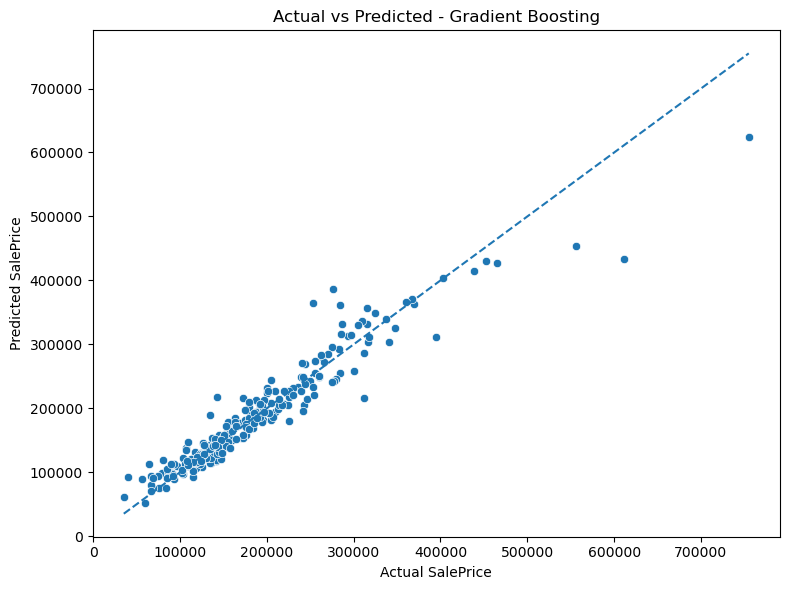

In [51]:
# ACTUAL VS PREDICTED PRICES

best_predictions = predictions[best_model_name]

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=best_predictions
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title(f"Actual vs Predicted - {best_model_name}")

# Perfect prediction line
min_price = min(y_test.min(), best_predictions.min())
max_price = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.tight_layout()
plt.show()

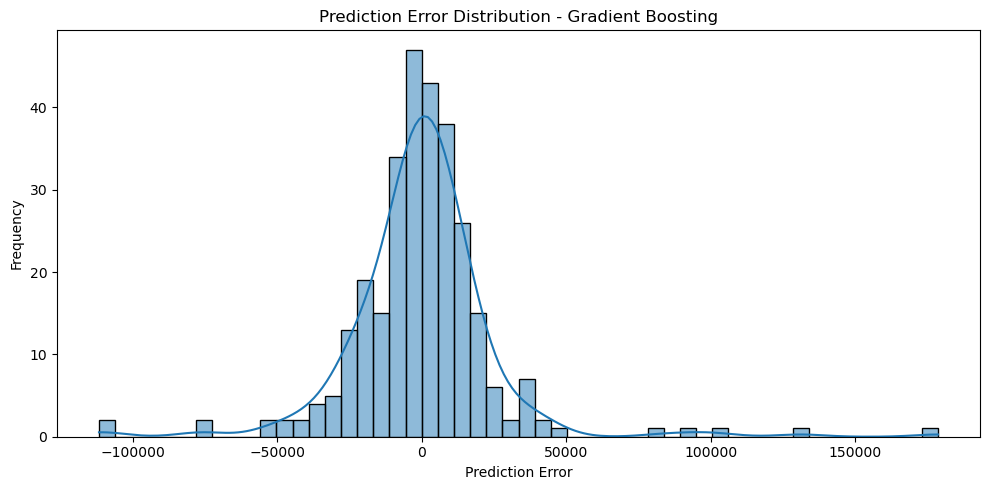

In [52]:
# PREDICTION ERROR DISTRIBUTION

errors = y_test - best_predictions

plt.figure(figsize=(10, 5))

sns.histplot(errors, kde=True)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title(f"Prediction Error Distribution - {best_model_name}")

plt.tight_layout()
plt.show()

In [53]:
# SAVE BEST MODEL PIPELINE

model_dir = "model"

os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(
    model_dir,
    "house_price_model.pkl"
)

joblib.dump(best_model, model_path)

print("Best model saved successfully!")
print("Model:", best_model_name)
print("Path :", model_path)

Best model saved successfully!
Model: Gradient Boosting
Path : model\house_price_model.pkl


In [54]:
# LOAD SAVED MODEL AND VERIFY

loaded_model = joblib.load(model_path)

test_prediction = loaded_model.predict(X_test.iloc[:5])

print("Model loaded successfully!")
print("\nSample predictions:")

for i, prediction in enumerate(test_prediction, start=1):
    print(f"House {i}: ${prediction:,.2f}")

Model loaded successfully!

Sample predictions:
House 1: $143,024.29
House 2: $349,607.06
House 3: $111,348.28
House 4: $150,912.67
House 5: $331,207.82


In [55]:
print("Dataset shape       :", data.shape)
print("Feature shape       :", X.shape)
print("Training samples    :", X_train.shape[0])
print("Testing samples     :", X_test.shape[0])
print("Models trained      :", len(model_pipelines))
print("Best model          :", best_model_name)
print("Best R2 Score       :", round(best_result["R2 Score"], 4))
print("Saved model path    :", model_path)

print("ML PIPELINE COMPLETED SUCCESSFULLY!")

Dataset shape       : (1460, 86)
Feature shape       : (1460, 84)
Training samples    : 1168
Testing samples     : 292
Models trained      : 4
Best model          : Gradient Boosting
Best R2 Score       : 0.915
Saved model path    : model\house_price_model.pkl
ML PIPELINE COMPLETED SUCCESSFULLY!


In [56]:
model_dir = "model"

os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(
    model_dir,
    "house_price_model.pkl"
)

joblib.dump(best_model, model_path)

print("Best model saved successfully!")
print("Path:", model_path)

Best model saved successfully!
Path: model\house_price_model.pkl
